# Programa de Ciencias de Datos

Mi primer ML

## **1**. Acceso a los datos

In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
datatrain = pd.read_csv('/content/sample_data/california_housing_train.csv', sep= ",")
datatrain.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
5268,-118.14,34.02,42.0,1384.0,458.0,1825.0,455.0,1.4178,145500.0
13156,-121.89,37.35,43.0,1185.0,296.0,933.0,244.0,2.9250,170800.0
2568,-117.65,34.07,35.0,2501.0,651.0,1182.0,591.0,1.4464,113200.0
9972,-119.76,36.74,52.0,2137.0,448.0,1194.0,444.0,1.3029,69100.0
2817,-117.72,34.03,17.0,2902.0,476.0,1652.0,479.0,5.6029,161800.0


In [ ]:
datatest = pd.read_csv('/content/sample_data/california_housing_test.csv', sep= ",")
datatest.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
2421,-121.21,39.24,7.0,4194.0,673.0,1355.0,566.0,4.3702,226100.0
186,-117.30,33.06,31.0,2128.0,520.0,1049.0,485.0,4.0270,290000.0
2589,-117.12,32.75,25.0,2222.0,634.0,1025.0,568.0,1.6400,130000.0
2648,-118.07,33.92,36.0,1560.0,320.0,1348.0,314.0,3.6220,174000.0
1817,-122.10,37.61,35.0,2361.0,458.0,1727.0,467.0,4.5281,173600.0


In [ ]:
print ("Tamaño de datos de entrenamiento: ", datatrain.shape)
print ("Tamaño de datos de prueba: ", datatest.shape)

Tamaño de datos de entrenamiento:  (17000, 9)
Tamaño de datos de prueba:  (3000, 9)


## **2**. Conjunto de Entrenamiento, Validación y prueba & Validación-Cruzada

En cualquier problema ML lo recomendable es trabajar con una triple partición del universo de datos: Entrenamiento, validación y prueba

Validación Cruzada

## **3**. Transformaciones durante el preprocesamiento

**Pipeline**: Tubería, facilita y automatiza el proceso de limpiado y preparación de los datos.

Transformaciones para variables numéricas:

* Imputación
* Transformaciones de distribución
* Normalización o estandariazación

In [ ]:
datatrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
sns.set(rc={'figure.figsize':(10,12)})

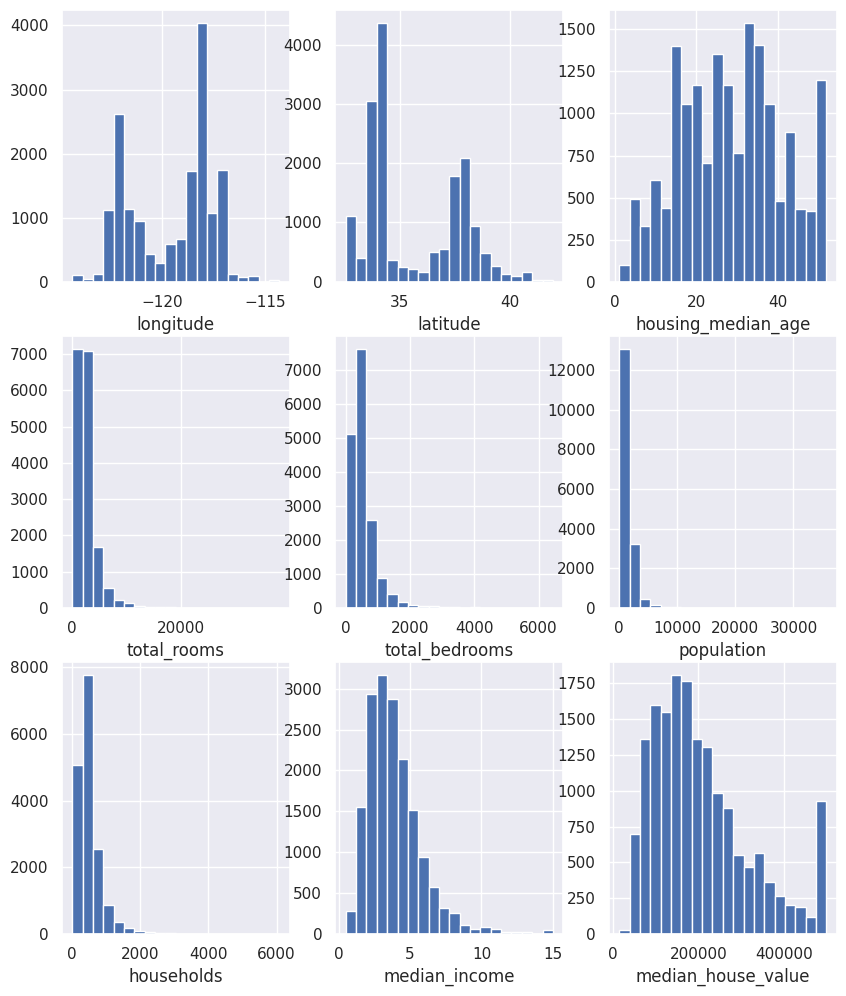

In [ ]:
fig, axes = plt.subplots(3, 3)    # Definimos una ventana de 3x3 nichos para incluir en cada uno de ellos un gráfico.

for k in range(0,9):

  plt.subplot(3,3,k+1)     # Los nichos para cada histograma se numeran iniciando en 1.

  plt.hist(datatrain[datatrain.columns[k]], bins=20)     # datatrain.columns nos devuelve una lista con los nombres de las columnas.

  plt.xlabel(datatrain.columns[k])

plt.show()

In [ ]:
datatrain.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


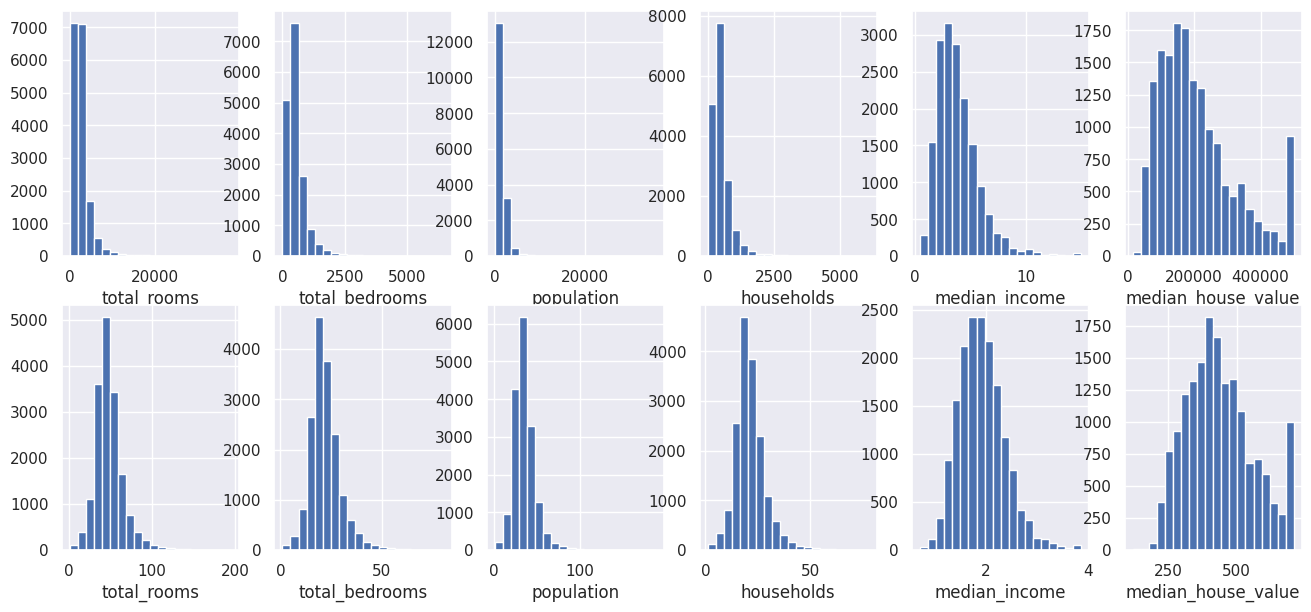

In [ ]:
sns.set(rc={'figure.figsize':(16,7)})



fig, axes = plt.subplots(2, 6)

for k in range(3,9):             # grafiquemos por el momento solo los factores con marcado sesgo positivo.

  plt.subplot(2,6,k-2)



  tmp = datatrain[datatrain.columns[k]]   # datos originales.

  plt.hist(tmp, bins=20)

  plt.xlabel(datatrain.columns[k])



  plt.subplot(2,6,k+4)

  tmp = np.sqrt(datatrain[datatrain.columns[k]])   # datos con alguna transformación para ajuste de la distribución.

  plt.hist(tmp, bins=20)

  plt.xlabel(datatrain.columns[k])



plt.show()

## **4.** Métricas de desempeño

In [ ]:
# Definimos nuestra función del coeficiente de determinación ajustado a partir de las fórmulas dadas anteriormente, donde:

#    y_true: valores observados reales

#    y_hat : predicciones



# Suma de cuadrados de los errores:

def mi_SSE(y_true, y_hat):

  return sum( np.square(y_true - y_hat))



# Suma de cuadrados de la variabilidad total:

def mi_Syy(y_true, ymtrain):    # observa que se usa el valor promedio de las observaciones del conjunto de entrenamiento ymtrain.

  return sum( np.square(y_true - ymtrain))



# Coeficiente de determinación ajustado:

def mi_R2adj(sse, syy, n, k):

  tmp = ((n-1) / (n-k-1)) * (sse/syy)     # n:total de registros. k: total de variables independientes (predictores).

  return 1 - tmp    # coeficiente de determinación ajustado R2adj

## **5**. Conjuntando todos los pasos para el entrenamiento del modelo de RLM

In [ ]:
# Librerías
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import KFold # Particiones de CV




In [ ]:
# Con los datos de entrenamiento
# se generaran las particiones de CV:

Xtrain = datatrain.drop('median_house_value', axis= 'columns')
ytrain = datatrain['median_house_value']

# Lo mismo para los datos de prueba:

Xtest = datatest.drop('median_house_value', axis= 'columns')
ytest = datatest['median_house_value']

**Preprocesamiento**

In [ ]:
num_prepro_pipelin = Pipeline (steps= [ ('imputar', SimpleImputer(strategy= 'mean')), #imputando por la media
                                        ('escalar', MinMaxScaler(feature_range=(1, 2)))]) #escalando MinmaxScaler 1,2

num_prepro_nombre = list(Xtrain.columns)

# Transformar raíz cuadrada para las variables con sesgos
num_raiz_pipeline = Pipeline(steps= [('raiz', FunctionTransformer(np.sqrt))]) #sqrt= raíz, transformación
num_raiz_nombre = ['total_rooms', 'total_bedrooms', 'population', 'household', 'median_income']


#Aplicamos las transformaciones a las variables indicadas
ColumnTransformers = ColumnTransformer(transformers= [('num_prepro', num_prepro_pipelin, num_prepro_nombre),
                                                     ('num_raiz', num_raiz_pipeline, num_raiz_nombre)],
                                                    remainder= 'passthrough')

In [ ]:
# Seleccionamos nuestro modelo de ML, en nuestro caso Regresión Lineal Múltiple RLM:
modelo_LR = LinearRegression()

#Cálculo de métricas de desempeño:
scoresR2Train = []
scoresR2Val = []
scoresmiR2Val = []
scoresR2adjVal = []
scoresRMSEVal = []

# Inicializamos la CV cross validation usadno KFOLD con k = 5 KFOLD son las particiones
k = 5
kf = KFold (n_splits= k, shuffle= True) #shuffle antes de hacer las particiones revuelve todos los datos




In [ ]:
# Aplicamos CV mediante la evaluación de c/u una de las k particiones:
for train_index, val_index in kf.split(Xtrain):

# En cada partición definimos ahora sí el conjunto de entrenamiento y el de validación:
X_train, X_val = Xtrain.iloc[train_index], Xtrain.iloc[val_index]
y_train, y_val = ytrain.iloc[train_index], ytrain.iloc[val_index]

# Aplicamos las transformaciones al conjunto de entrenamiento
XtrainFit = Columnas
